In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer,load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,roc_curve,roc_auc_score
from sklearn import metrics
import numpy as np

Dataset 1:Breast cancer

In [7]:
data=load_breast_cancer()
X=data.data
y=data.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=23)

train model

In [11]:
model=LogisticRegression(max_iter=10000)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)


accuracy


In [12]:
accuracy=accuracy_score(y_test,y_pred)*100
print("breast cancer Accuracy:",accuracy)


breast cancer Accuracy: 96.49122807017544


Confusion matrix vizualization

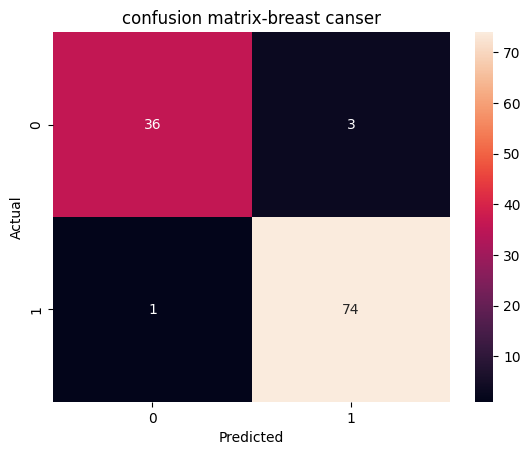

In [13]:
cm=confusion_matrix(y_test,y_pred)
plt.figure()
sns.heatmap(cm,annot=True,fmt='d')
plt.title("confusion matrix-breast canser")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

roc curve

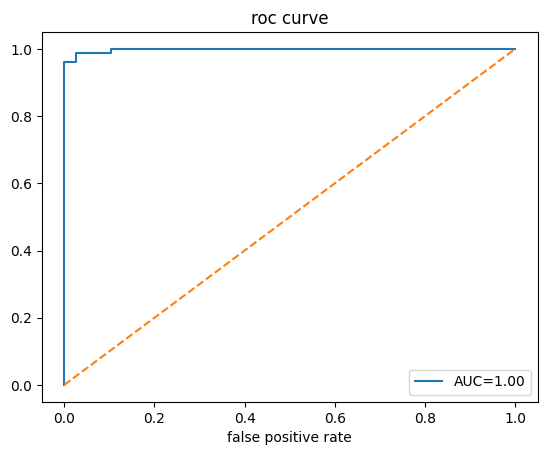

In [14]:
y_prob=model.predict_proba(X_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
auc_score=roc_auc_score(y_test,y_prob)
plt.figure()
plt.plot(fpr,tpr,label="AUC=%.2f"%auc_score)
plt.plot([0,1],[0,1],"--")
plt.xlabel("false positive rate")
plt.title("roc curve")
plt.legend()
plt.show()

sigmoid function

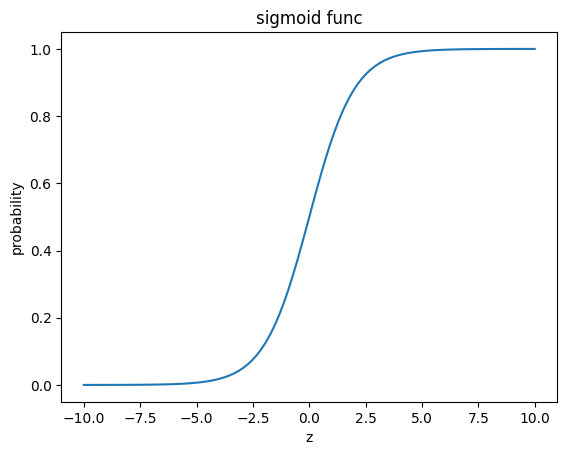

In [16]:
z=np.linspace(-10,10,100)
sigmoid=1/(1+np.exp(-z))
plt.figure()
plt.plot(z,sigmoid)
plt.title("sigmoid func")
plt.xlabel("z")
plt.ylabel("probability")
plt.show()

digits dataset

In [17]:
digits=load_digits()
X=digits.data
y=digits.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.4,random_state=1)
reg=LogisticRegression(max_iter=10000)
reg.fit(X_train,y_train)
y_pred=reg.predict(X_test)
accuracy=metrics.accuracy_score(y_test,y_pred)*100
print("digits accuracy:",accuracy)


digits accuracy: 96.66203059805285


sample digit images

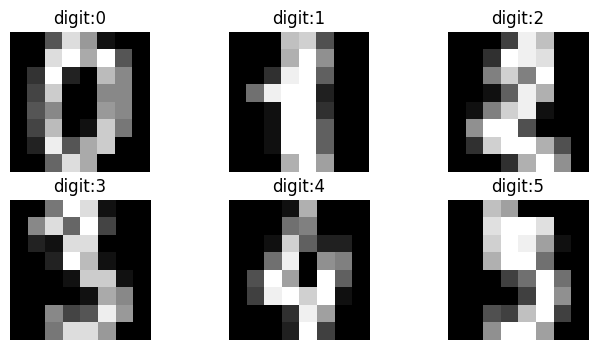

In [24]:
plt.figure(figsize=(8,4))
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.imshow(digits.images[i],cmap="gray")
  plt.title("digit:"+str(digits.target[i]))
  plt.axis("off")
